# Bees production 

### Setup

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import utils
import matplotlib.pyplot as plt
import importlib
importlib.reload(utils)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

honey_production_df, apistox_df, inspections_on_weather_dict = utils.load_base_datasets()
honey_production_df_copy = honey_production_df.copy()


 honey_production_df (1115, 9) : Done! 

 apistox_df (1035, 13) : Done! 

 Apiary_Information.csv (13, 4) : Done!
 HCC_Inspections.csv (2404, 11) : Done!
 Hive_Information.csv (188, 3) : Done!
 Hourly_Weather.csv (3672, 15) : Done!
 Weather_Observations.csv (1776, 4) : Done!
 Weather_Stations.csv (3, 3) : Done!

Datasets collection completed.


## Part 1: Honey production 

In [2]:
honey_production_df = honey_production_df_copy.copy()

#cleaning the dataset
honey_production_df.drop(columns=["Unnamed: 0"], inplace=True)
for state in honey_production_df.state.unique():
    state_production = honey_production_df[honey_production_df.state == state]
    #keeping states that have data for all the 27 years from 1995 to 2021
    if len(state_production) < 27:
        honey_production_df.drop(state_production.index, inplace=True)

n_states = honey_production_df.state.nunique()
utils.EDA(honey_production_df, head = n_states) #to show the first data for all the considered states

honey_production_df_copy = honey_production_df.copy()

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
Index: 1026 entries, 0 to 1114
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                1026 non-null   object 
 1   colonies_number      1026 non-null   int64  
 2   yield_per_colony     1026 non-null   int64  
 3   production           1026 non-null   int64  
 4   stocks               1026 non-null   int64  
 5   average_price        1026 non-null   float64
 6   value_of_production  1026 non-null   int64  
 7   year                 1026 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 72.1+ KB


##-------------- DESCRIBE --------------------------##
        colonies_number  yield_per_colony    production        stocks  \
count      1026.000000       1026.000000  1.026000e+03  1.026000e+03   
mean      67181.286550         60.496101  3.071741e+06  1.265299e+06   
std   

### Production Analysis 

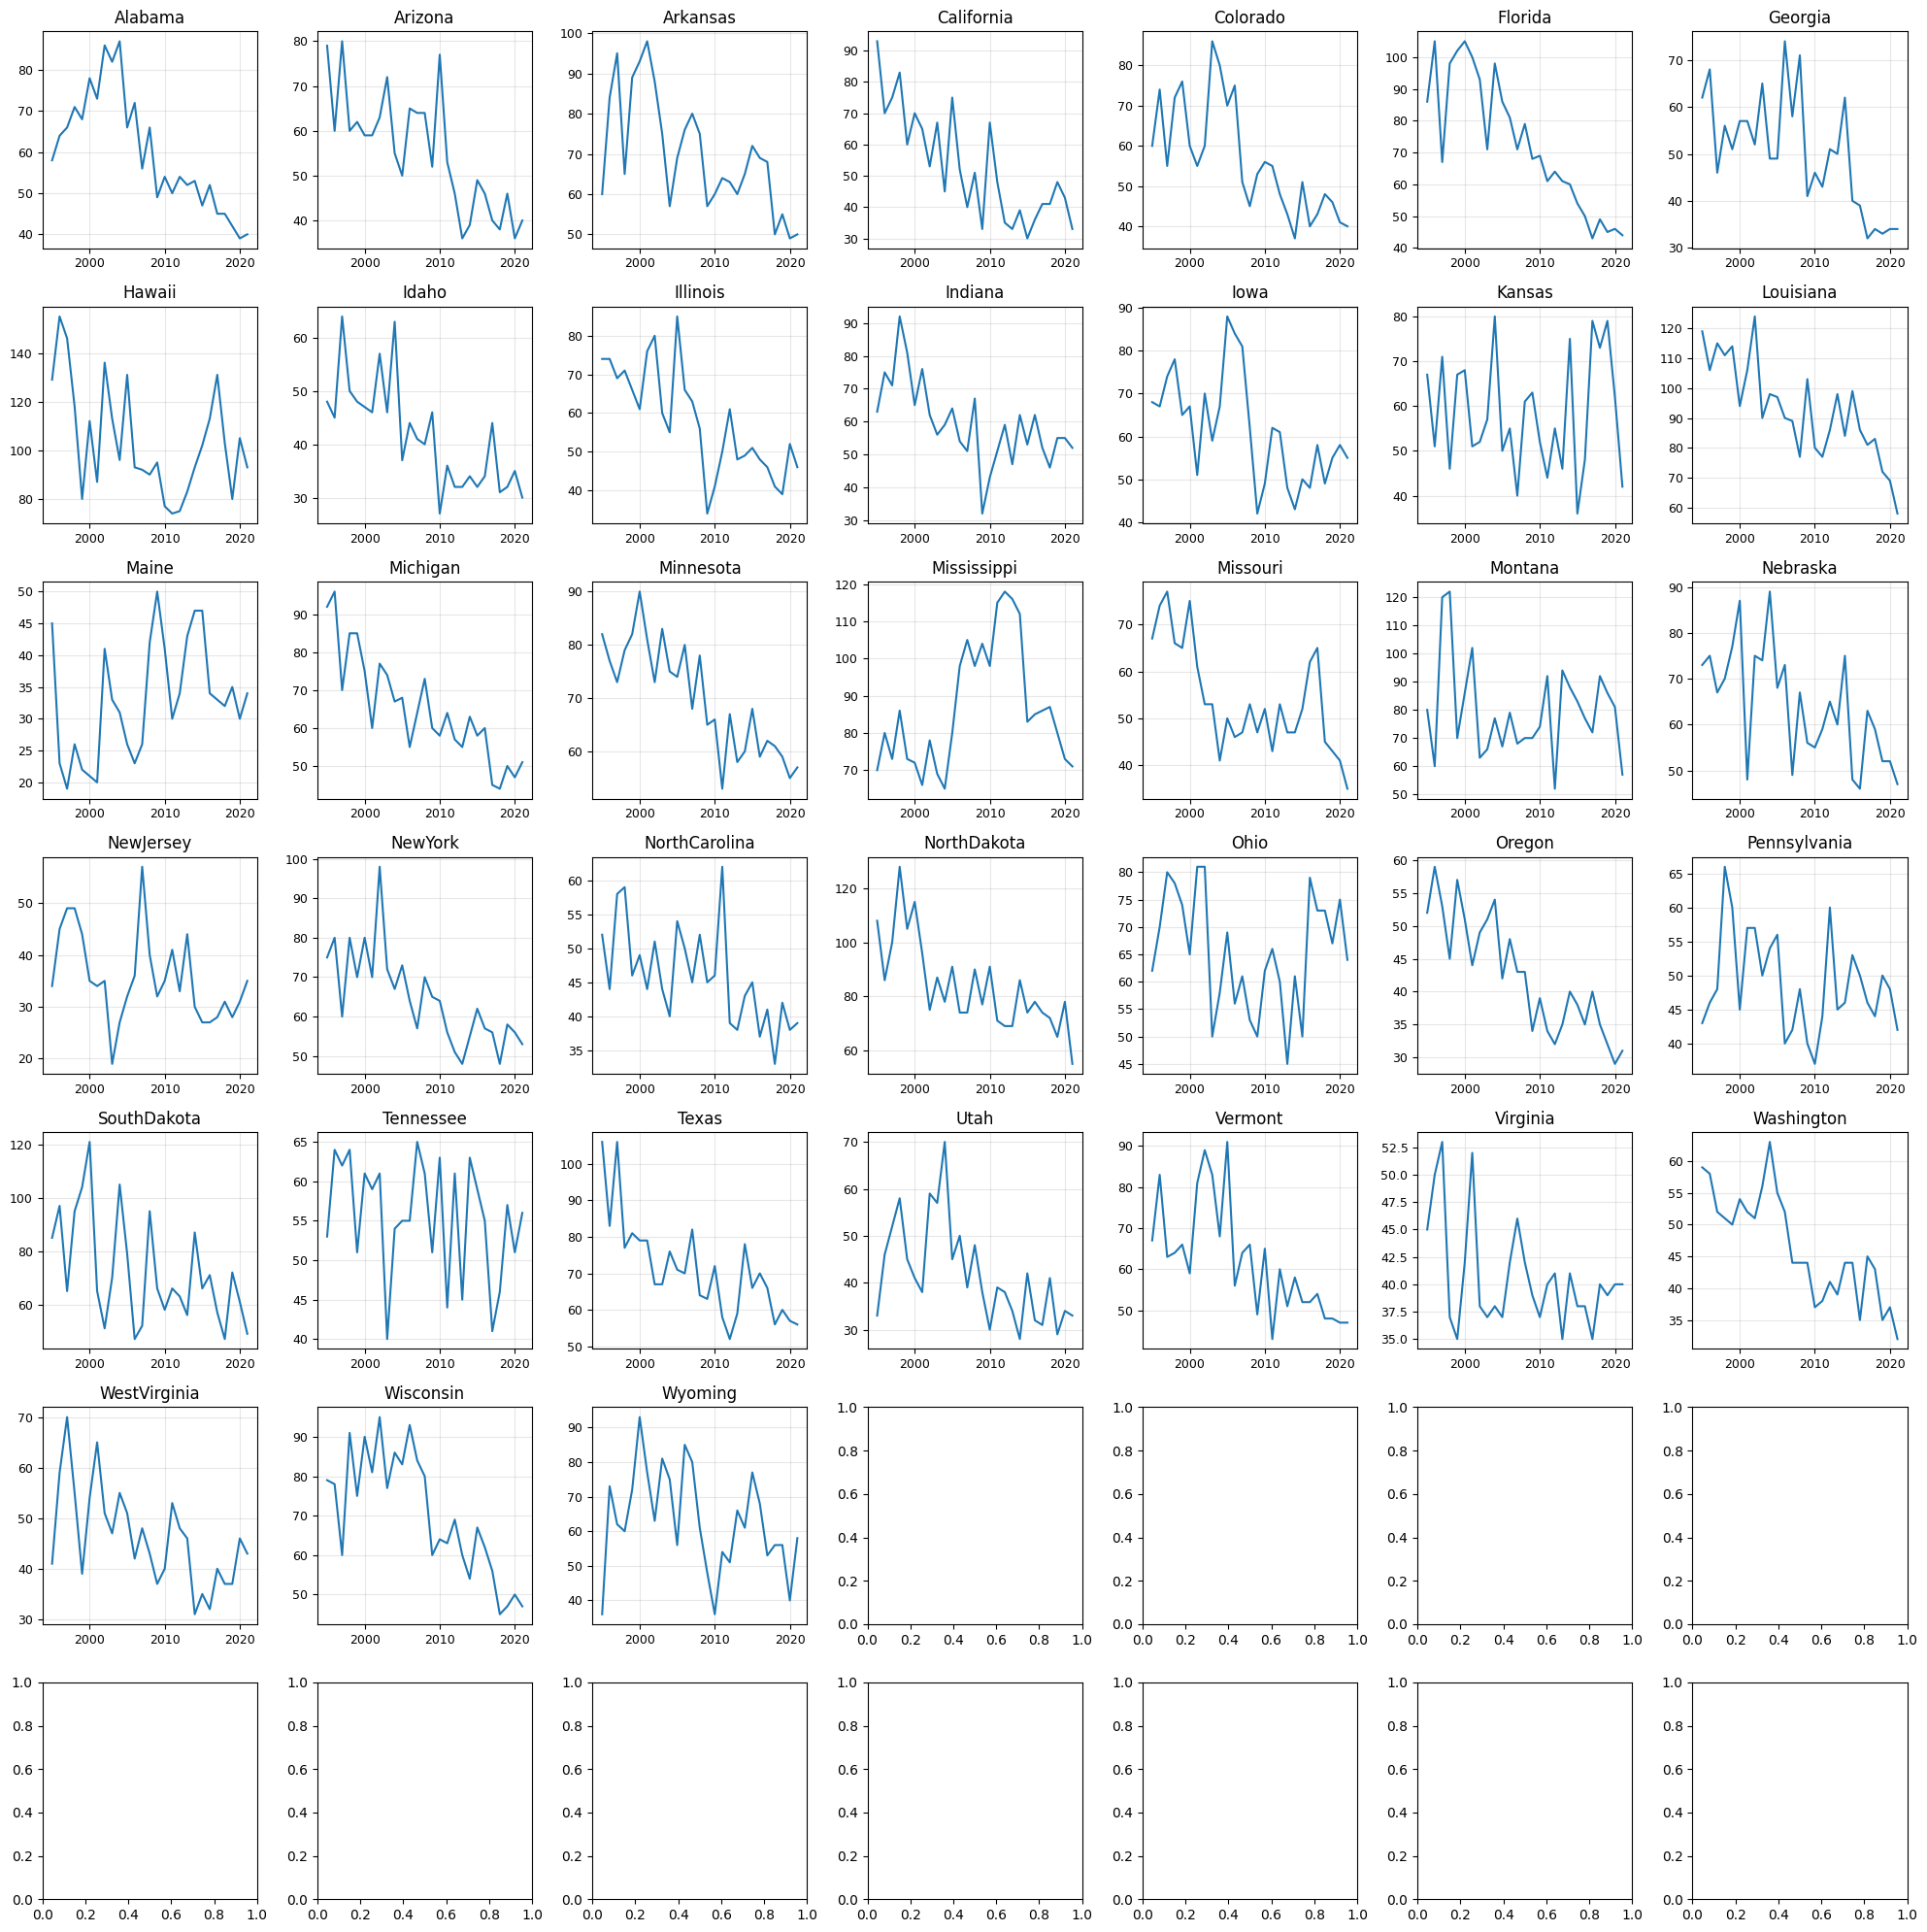

In [3]:
utils.plot_all(honey_production_df, "state", "year", "yield_per_colony")

### Production Trend Prediction

0.8217742830203364


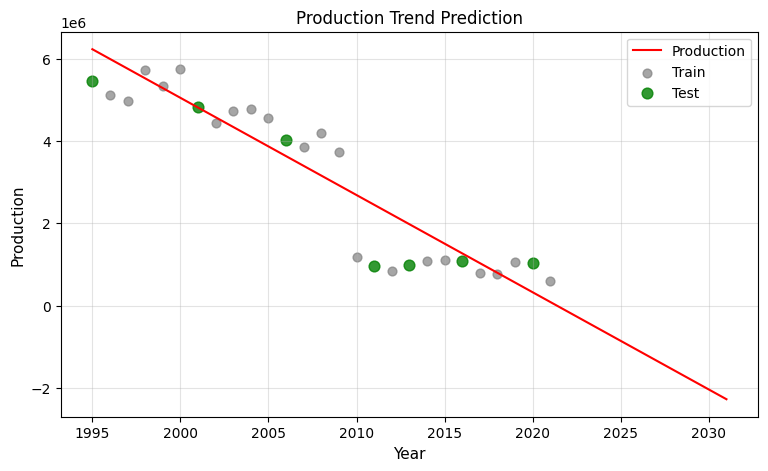

In [4]:
#setting up data
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means, 
                                                    test_size=0.25,
                                                    random_state=30)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Production")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

### Price analysis

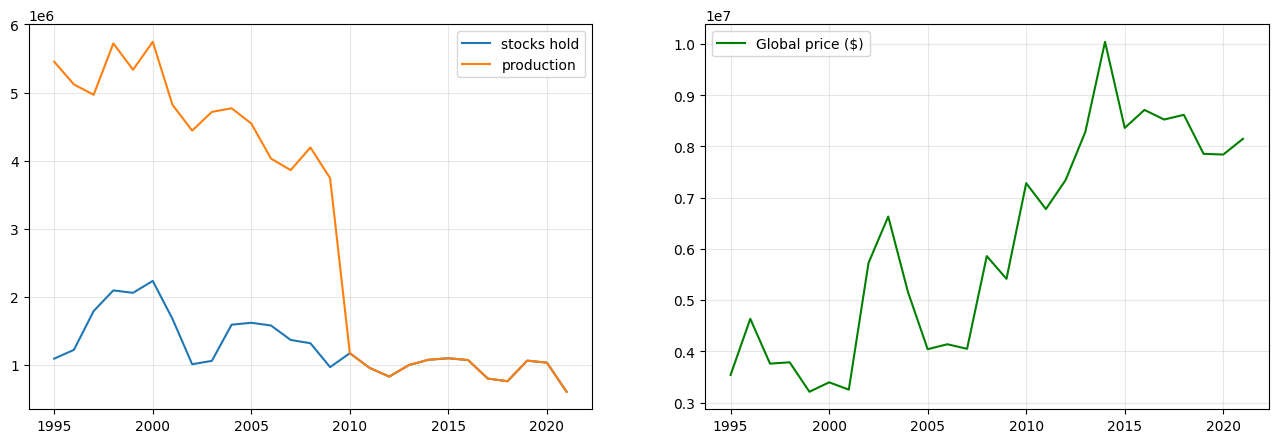

In [5]:
figure = plt.figure(figsize=(16,5))
plot1 = figure.add_subplot(1,2,1)
plot2 = figure.add_subplot(1,2,2)
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["stocks"].mean(), label = "stocks hold")
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["production"].mean(), label = "production")
plot2.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["value_of_production"].mean(), label = "Global price ($)", color = "green")
plot1.legend()
plot2.legend()
plot1.grid(alpha = 0.3)
plot2.grid(alpha = 0.3)

### Price Trend Prediction 

0.7937643373061338


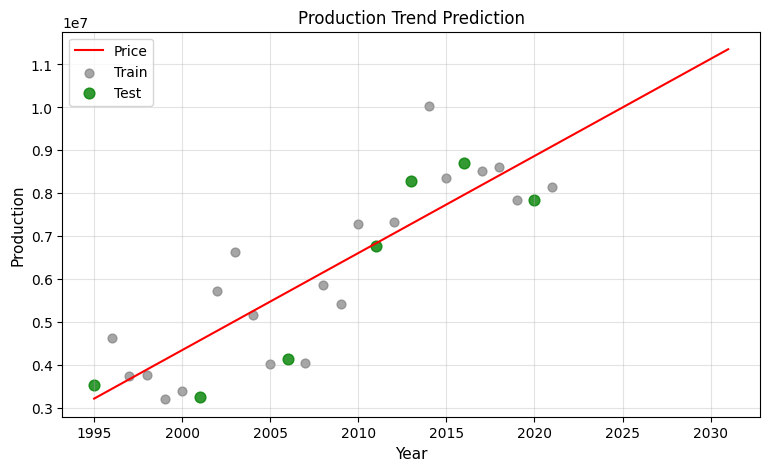

In [6]:
#setting up data
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["value_of_production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means, 
                                                    test_size=0.25,
                                                    random_state=30)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Price")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

## Part 2: Apistox 

In [2]:
utils.EDA(apistox_df, head = 7)

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                1035 non-null   object
 1   CID                 1035 non-null   int64 
 2   CAS                 1035 non-null   object
 3   SMILES              1035 non-null   object
 4   source              1035 non-null   object
 5   year                1035 non-null   int64 
 6   toxicity_type       1035 non-null   object
 7   herbicide           1035 non-null   int64 
 8   fungicide           1035 non-null   int64 
 9   insecticide         1035 non-null   int64 
 10  other_agrochemical  1035 non-null   int64 
 11  label               1035 non-null   int64 
 12  ppdb_level          1035 non-null   int64 
dtypes: int64(8), object(5)
memory usage: 105.2+ KB


##-------------- DESCRIBE --------------------------##
        

### Further setup

In [20]:
#the following row alone can be of interest
#pesticide_usage_df = utils.load_pesticide_usage_datasets()

pesticide_usage_df = utils.apistox_support_setup(remove_kg=False)

apistox_complete_df = apistox_df.merge(pesticide_usage_df)
apistox_complete_df.drop(["name", "source", "SMILES", "CID","other_agrochemical", "year"], axis = 1, inplace=True)
apistox_complete_df.columns = apistox_complete_df.columns.map(str.upper)

apistox_complete_df_copy = apistox_complete_df.copy()


 pesticide_usage_df (107742, 6) - year 2019: Done! 



### Apistox analysis

In [18]:
utils.EDA(apistox_complete_df)

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6278 entries, 0 to 6277
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CAS            6278 non-null   object 
 1   TOXICITY_TYPE  6278 non-null   object 
 2   HERBICIDE      6278 non-null   int64  
 3   FUNGICIDE      6278 non-null   int64  
 4   INSECTICIDE    6278 non-null   int64  
 5   LABEL          6278 non-null   int64  
 6   PPDB_LEVEL     6278 non-null   int64  
 7   COMPOUND       6278 non-null   object 
 8   YEAR           6278 non-null   int64  
 9   MEAN_KG        6278 non-null   float64
 10  STATE_NAME     6278 non-null   object 
dtypes: float64(1), int64(6), object(4)
memory usage: 539.6+ KB


##-------------- DESCRIBE --------------------------##
          HERBICIDE    FUNGICIDE  INSECTICIDE        LABEL   PPDB_LEVEL  \
count  6278.000000  6278.000000   6278.00000  6278.000000  6278.00000

### Apistox Classification (Variety of Pesticides)

In [21]:
first_target = apistox_complete_df.PPDB_LEVEL
second_target = apistox_complete_df.LABEL

results, _ = utils.random_forest(apistox_complete_df[["HERBICIDE", "FUNGICIDE", "INSECTICIDE", "TOXICITY_TYPE"]],
                    first_target,
                    n_estimators=750,
                    random_state=42)
results

Score:  0.7444444444444445


,Features,Weight %
0,INSECTICIDE,0.545071
1,HERBICIDE,0.177301
2,FUNGICIDE,0.139658
3,TOXICITY_TYPE_Contact,0.065129
4,TOXICITY_TYPE_Oral,0.053529
5,TOXICITY_TYPE_Other,0.019312


/tmp/ipykernel_96509/3392253395.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  apistox_complete_df["ORDER"] += apistox_complete_df[column] * float(results_feature_indexed.loc[column])


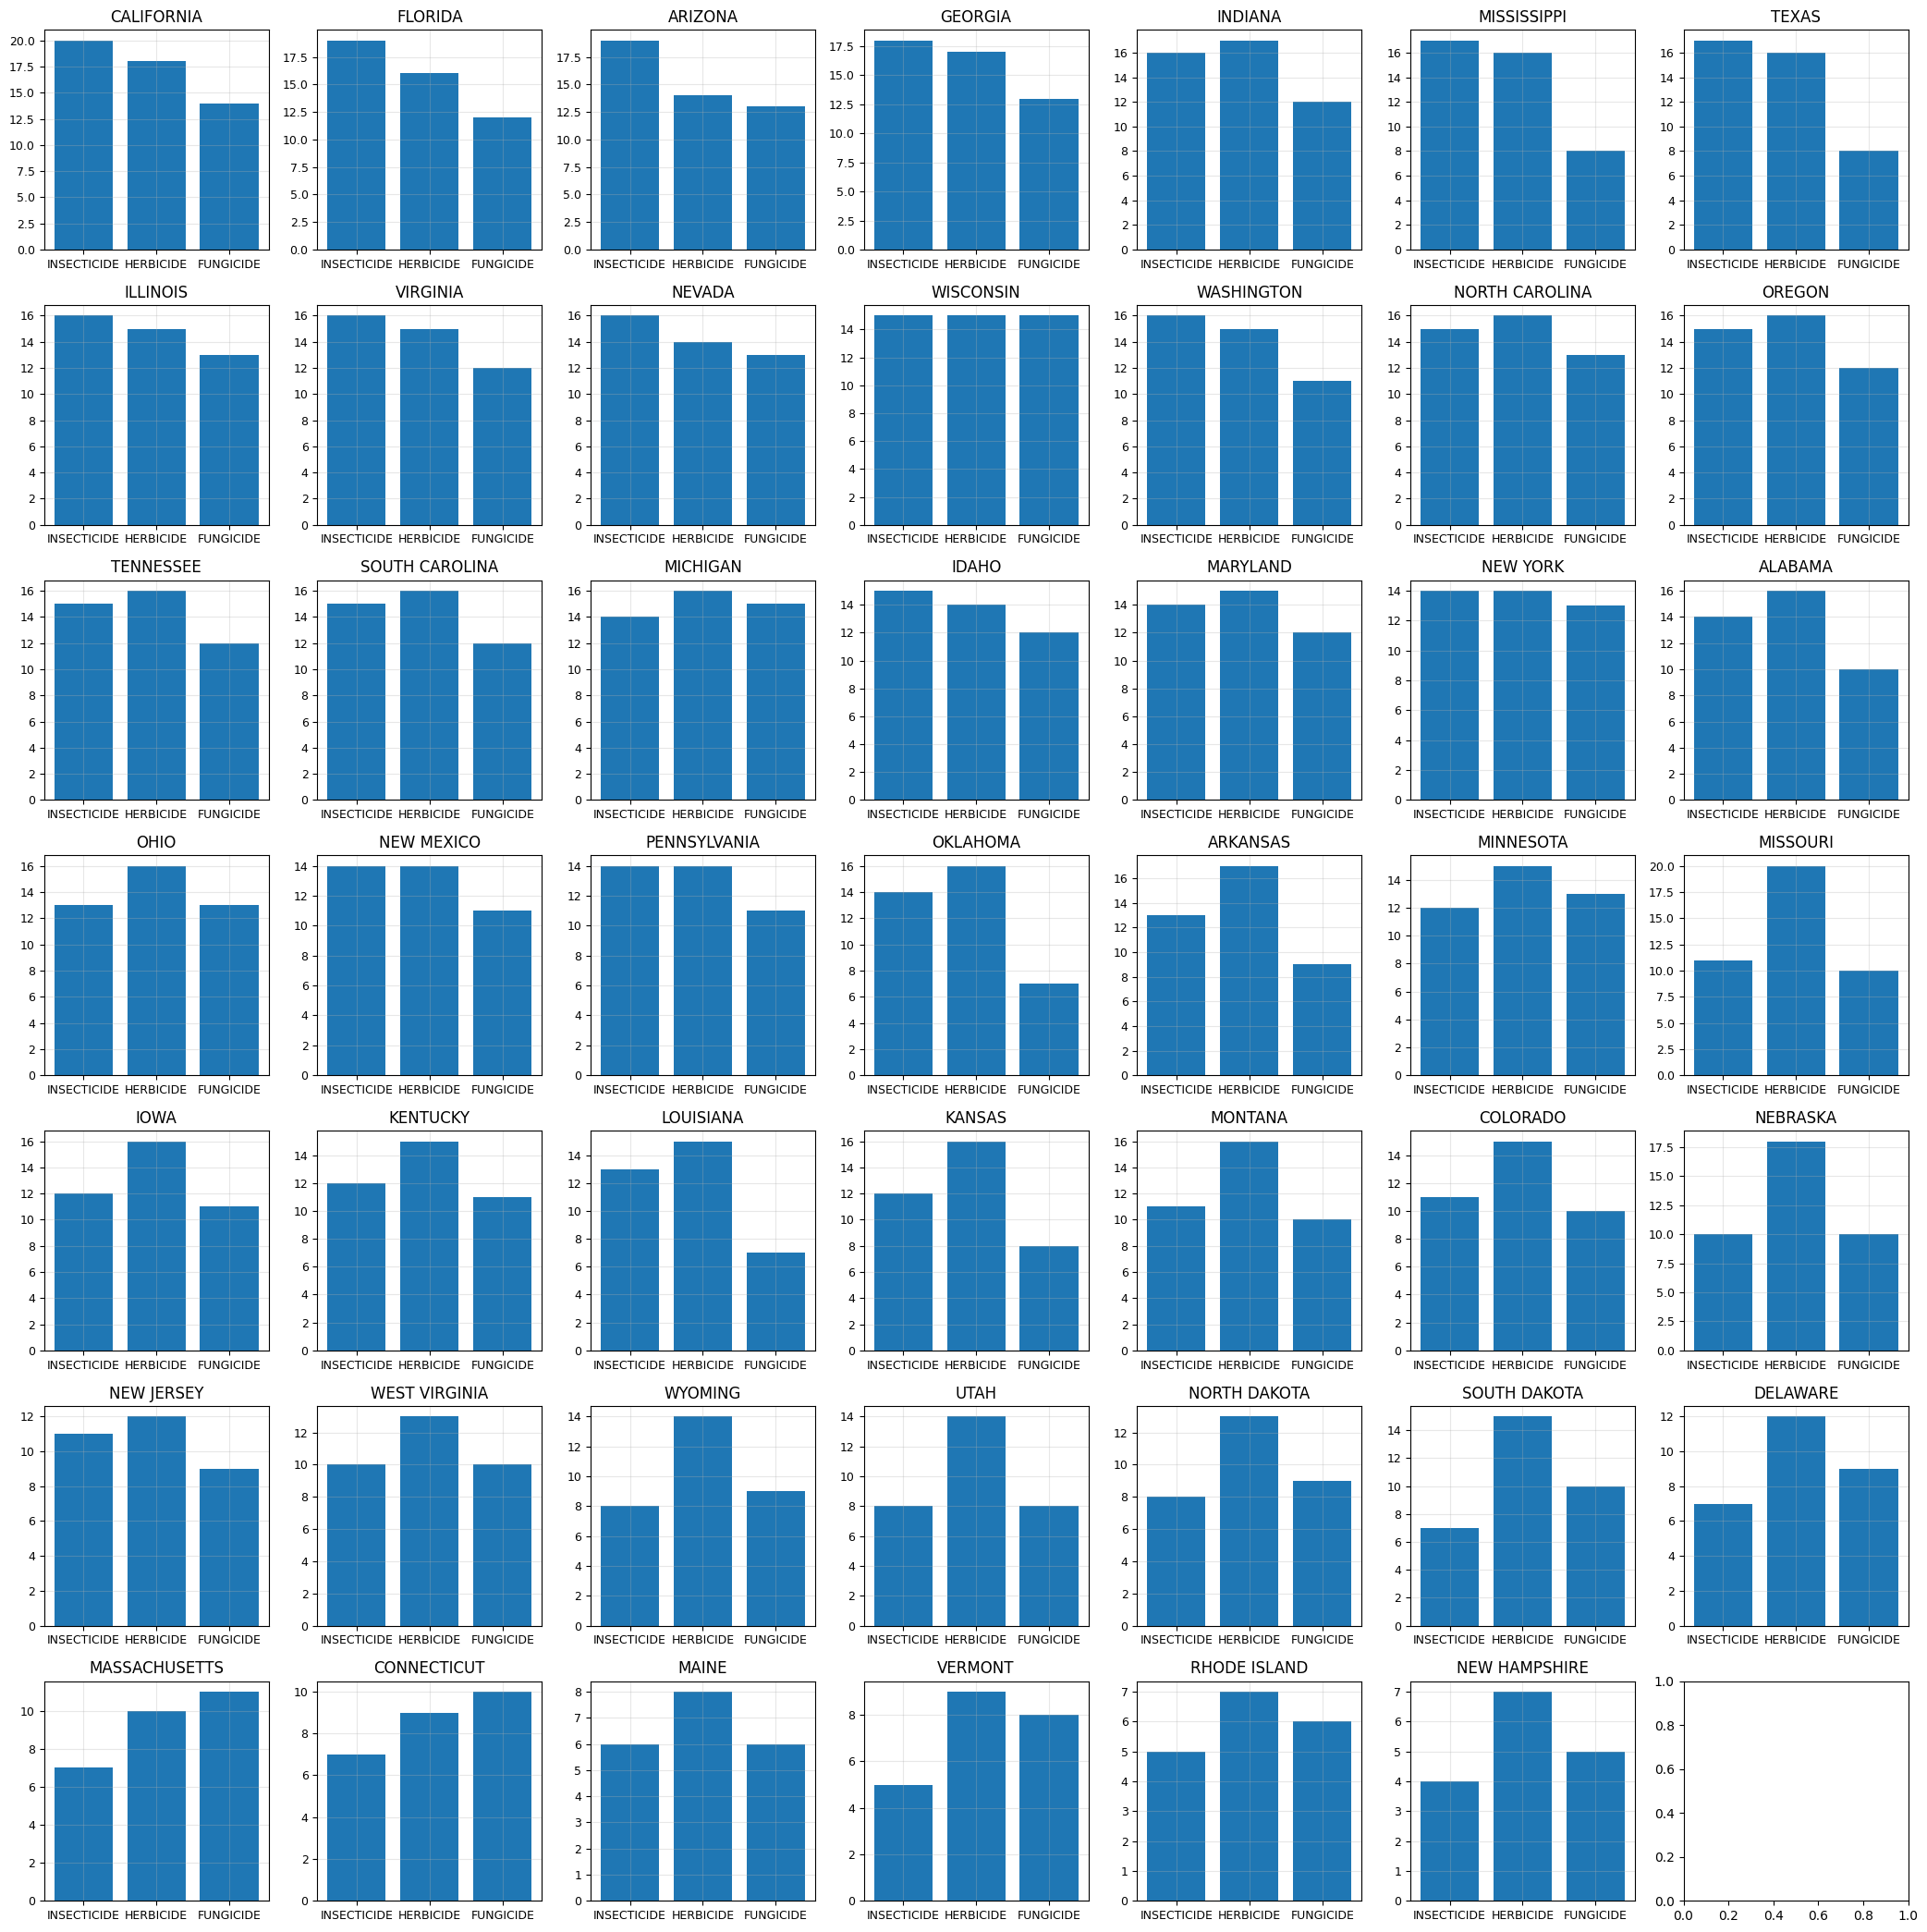

In [22]:
apistox_complete_df = apistox_complete_df_copy

apistox_complete_df
results_feature_indexed = results.set_index("Features")
# #correctly giving weight to the information we are interested in
apistox_complete_df = apistox_complete_df.groupby("STATE_NAME")[["INSECTICIDE","HERBICIDE", "FUNGICIDE"]].sum()

apistox_complete_df["ORDER"] = 0
for column in apistox_complete_df.columns[:3]:
    #:TODO fallo con iloc
    apistox_complete_df["ORDER"] += apistox_complete_df[column] * float(results_feature_indexed.loc[column])

apistox_complete_df = apistox_complete_df.sort_values("ORDER", ascending=False).drop("ORDER", axis = 1)
utils.bar_all(apistox_complete_df,apistox_complete_df.columns,["INSECTICIDE","HERBICIDE", "FUNGICIDE"])

variety_order = apistox_complete_df.reset_index()["STATE_NAME"].rename("VARIETY_ORDER")

### Apistox Analysis (Quantity of Pesticides)

In [23]:
apistox_complete_df = apistox_complete_df_copy
first_target = apistox_complete_df.PPDB_LEVEL
second_target = apistox_complete_df.LABEL

results_label, _ = utils.random_forest(apistox_complete_df[["HERBICIDE", "FUNGICIDE", "INSECTICIDE", "TOXICITY_TYPE", "MEAN_KG"]],
                    first_target,
                    n_estimators=750,
                    random_state=42)
print("Impact on label:\n", results_label)
print("...........")
results_level, _ = utils.random_forest(apistox_complete_df[["HERBICIDE", "FUNGICIDE", "INSECTICIDE", "TOXICITY_TYPE", "MEAN_KG"]],
                    second_target,
                    n_estimators=750,
                    random_state=42)
print("Impact on PPDB_LEVEL:\n", results_level)



Score:  0.6166666666666667
Impact on label:
                 Features  Weight %
0                MEAN_KG  0.663451
1            INSECTICIDE  0.176964
2              HERBICIDE  0.062751
3              FUNGICIDE  0.046777
4  TOXICITY_TYPE_Contact  0.024611
5     TOXICITY_TYPE_Oral  0.018901
6    TOXICITY_TYPE_Other  0.006546
...........
Score:  0.9305555555555556
Impact on PPDB_LEVEL:
                 Features  Weight %
0            INSECTICIDE  0.500884
1                MEAN_KG  0.177882
2              HERBICIDE  0.165040
3              FUNGICIDE  0.140418
4    TOXICITY_TYPE_Other  0.005730
5  TOXICITY_TYPE_Contact  0.005578
6     TOXICITY_TYPE_Oral  0.004468


In [25]:
apistox_complete_df = apistox_complete_df_copy
apistox_complete_df = apistox_complete_df.groupby("STATE_NAME")[["MEAN_KG"]].sum().sort_values("MEAN_KG", ascending=False).reset_index()["STATE_NAME"].rename("QUANTITY_ORDER")

usage_ranking_df = pd.concat([variety_order, apistox_complete_df], axis = 1)

variety_order_idx = usage_ranking_df.index.to_list()
quantity_order_idx = []
for state in usage_ranking_df.VARIETY_ORDER:
    #TODO loc
    quantity_order_idx.append(usage_ranking_df[usage_ranking_df["QUANTITY_ORDER"] == state].index[0])

usage_ranking_df["POS_DIFF"] = np.abs(pd.Series(variety_order_idx) - pd.Series(quantity_order_idx))

conditions = [
    usage_ranking_df["POS_DIFF"] == 0,
    usage_ranking_df["POS_DIFF"] <= 3, 
    usage_ranking_df["POS_DIFF"] <= 5,
    usage_ranking_df["POS_DIFF"] <= 10,
]

distance_labels = ["SAME POSITION", "VERY CLOSE", "CLOSE", "DISTANT"]

usage_ranking_df["POS_CHANGE"] = np.select(conditions, distance_labels, "VERY DISTANT")
usage_ranking_df.drop("POS_DIFF",axis=1, inplace =True)
usage_ranking_df

,VARIETY_ORDER,QUANTITY_ORDER,POS_CHANGE
0,CALIFORNIA,KANSAS,DISTANT
1,FLORIDA,IOWA,VERY DISTANT
2,ARIZONA,NEBRASKA,VERY DISTANT
3,GEORGIA,ILLINOIS,VERY DISTANT
4,INDIANA,TEXAS,VERY CLOSE
5,MISSISSIPPI,MINNESOTA,DISTANT
6,TEXAS,NORTH DAKOTA,VERY CLOSE
7,ILLINOIS,INDIANA,CLOSE
8,VIRGINIA,MISSOURI,VERY DISTANT
9,NEVADA,SOUTH DAKOTA,VERY DISTANT


## Part 3: Weather Effects on Bees' Health


### Further Setup

#### Note
"HCC_Inspections": contains the inspections result, together with with the percentage of requirements met. An hive is health iff all requirements are set to 1.

    - Brood: all phases of a brood are present (egg, larvae, pupae)
    - Bees: there are enough bees in the hive to manage it and defend it
    - Queen: the queen is alive, young and can reproduce
    - Food: there's enough food and source of found outside
    - Stressors: there are no stressors 
    - Space: the space is safe, clean and not in detriment 

"Hourly_Weather": contains an analysis of the weather during the recorded hour.
Important notes:

    - Degrees are in Fahrenheit
    - Wind_Gust represents the peak of speed during a recorded interval

In [43]:
# The dictionary containing the data for the third part of the analysis is loaded twice only for visualization purpose: 
# it is made possible to just use and visualize the dictionary with all the tables yet to be merged, if necessary.
table = inspections_on_weather_dict["HCC_Inspections"]
utils.EDA(table)

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2404 entries, 0 to 2403
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InpsectionID  2404 non-null   int64  
 1   HiveID        2404 non-null   int64  
 2   InsptDate     2402 non-null   object 
 3   Brood         2388 non-null   float64
 4   Bees          2388 non-null   float64
 5   Queen         2388 non-null   float64
 6   Food          2400 non-null   float64
 7   Stressors     2389 non-null   float64
 8   Space         2388 non-null   float64
 9   Percent_Met   2404 non-null   int64  
 10  Healthy       2404 non-null   object 
dtypes: float64(6), int64(3), object(2)
memory usage: 206.7+ KB


##-------------- DESCRIBE --------------------------##
        InpsectionID       HiveID        Brood         Bees        Queen  \
count   2404.000000  2404.000000  2388.000000  2388.000000  2388.000000   
mean  

In [44]:
inspections_on_weather_df = utils.load_complete_inspections_on_weather_df()

inspections_on_weather_df
inspections_on_weather_df_copy = inspections_on_weather_df.copy()

 honey_production_df (1115, 9) : Done! 

 apistox_df (1035, 13) : Done! 

 Apiary_Information.csv (13, 4) : Done!
 HCC_Inspections.csv (2404, 11) : Done!
 Hive_Information.csv (188, 3) : Done!
 Hourly_Weather.csv (3672, 15) : Done!
 Weather_Observations.csv (1776, 4) : Done!
 Weather_Stations.csv (3, 3) : Done!

Datasets collection completed.


### Apiatory part analysis

In [45]:
utils.EDA(inspections_on_weather_df)

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
Index: 33782 entries, 0 to 33935
Data columns (total 37 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   STATIONID       33782 non-null  int64         
 1   CITY_X          33782 non-null  object        
 2   STATION         33782 non-null  object        
 3   WEATHERID       33782 non-null  int64         
 4   OBSID           33782 non-null  int64         
 5   TEMPERATURE     33782 non-null  int64         
 6   HUMIDITY        33782 non-null  int64         
 7   DEW_POINT       33782 non-null  int64         
 8   WIND_DIRECTION  33782 non-null  object        
 9   WIND_SPEED      33782 non-null  int64         
 10  WIND_GUST       33782 non-null  int64         
 11  PRESSURE        33782 non-null  float64       
 12  PRECIP          33782 non-null  float64       
 13  CONDITION       33782 non-null  object        
 14  SUN

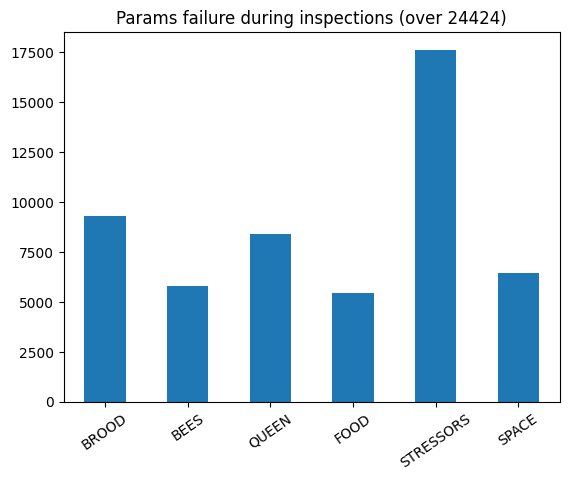

In [46]:
inspections_on_weather_df = inspections_on_weather_df_copy
failed_rows = inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0].shape[0]
failed_params = inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0][["BROOD", "BEES", "QUEEN", "FOOD", "STRESSORS", "SPACE"]].sum()
failed_params = failed_rows - failed_params 
plot = failed_params.plot(kind = "bar", 
                   title = f"Params failure during inspections (over {inspections_on_weather_df[inspections_on_weather_df.HEALTHY == 0].shape[0]})")
plot.tick_params(axis = "x", rotation = 35)

In [47]:
inspections_on_weather_df = inspections_on_weather_df_copy
inspections_on_weather_df.groupby("STATE")[[ "BROOD", "BEES", "QUEEN", "FOOD", "STRESSORS", "SPACE", "HEALTHY"]].mean()

,BROOD,BEES,QUEEN,FOOD,STRESSORS,SPACE,HEALTHY
STATE,,,,,,,
NORTHCAROLINA,0.713310,0.814032,0.746993,0.824501,0.437545,0.792737,0.237922
UTAH,0.833333,0.984127,0.793651,0.984127,0.888889,0.984127,0.674603


### Weather elements impact Classification

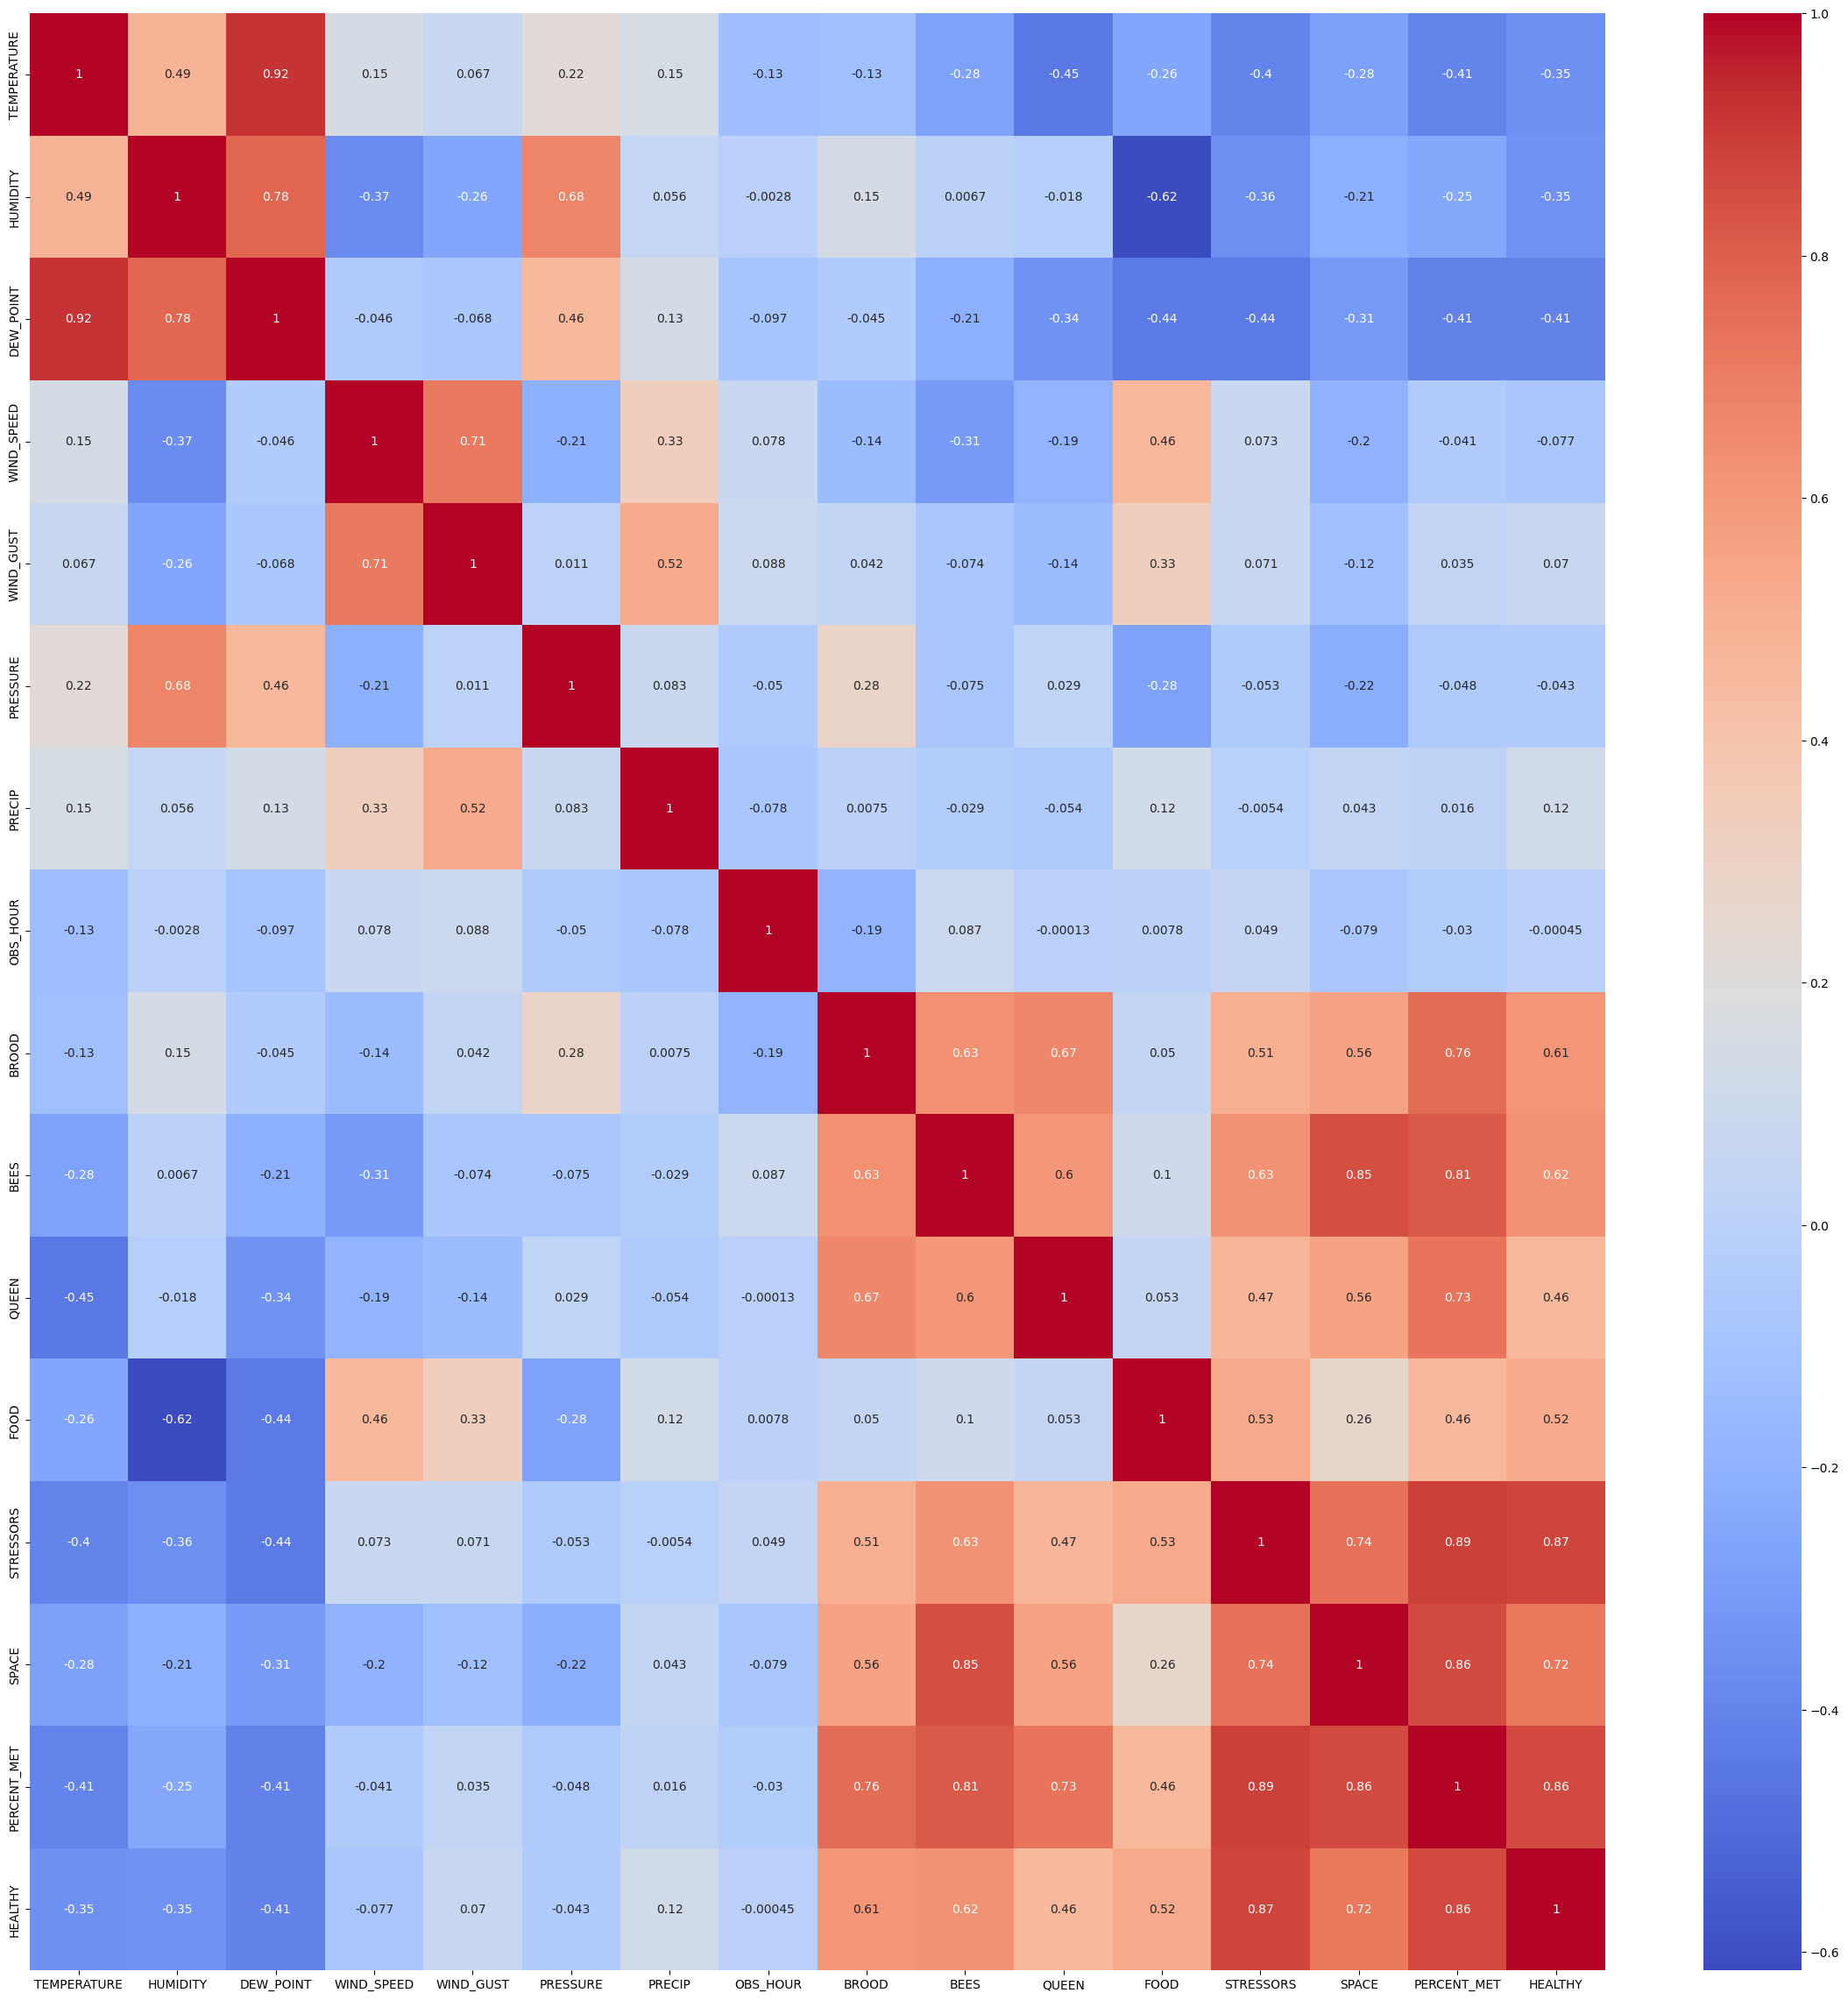

In [48]:
inspections_on_weather_df = inspections_on_weather_df_copy
inspections_on_weather_df = inspections_on_weather_df.drop(["STATIONID", "WEATHERID", "OBSID", "APIARYID", "HIVEID", "INSPECTIONID"],axis = 1)
inspections_on_weather_df = inspections_on_weather_df.groupby(["STATE", "YEAR", "MONTH"])

inspections_on_weather_df = inspections_on_weather_df.mean(numeric_only=True).round(3)

plt.figure(figsize=(29,29))
sns.heatmap(inspections_on_weather_df.corr(), annot=True, cmap="coolwarm")
plt.show()

Even though NC uses more pesticides (both in variety and in quantity) than UT, and considering also that hives in Utah more often pass the inspections compared to the NC hives, the fact that NC's honey production is higher is more likely due to the weather and environmental condition in the territory: UT has less precipitation and the territory is basically dry and characterized by deserts, nulike NC who also faces the ocean and is mostly composed of plains than UT.

In [49]:
inspections_on_weather_df = inspections_on_weather_df_copy
inspections_on_weather_df.groupby(["STATE", "YEAR"])[["PERCENT_MET", "TEMPERATURE", "HUMIDITY", "DEW_POINT", "WIND_SPEED", "WIND_GUST", "PRESSURE", "PRECIP"]].mean()

PERCENT_MET  TEMPERATURE   HUMIDITY  DEW_POINT  \
STATE         YEAR                                                   
NORTHCAROLINA 2016    77.308352    73.008172  72.355392  62.615707   
              2017    69.597761    69.895290  68.416329  57.686161   
UTAH          2016    91.500000    59.916667  74.416667  50.541667   
              2017    93.375000    68.045139  66.389757  54.809896   
              2019    82.653846    59.400641  42.036859  34.535256   

                    WIND_SPEED  WIND_GUST   PRESSURE    PRECIP  
STATE         YEAR                                              
NORTHCAROLINA 2016    4.961929   0.631254  29.646614  0.002392  
              2017    7.226211   2.847037  29.564369  0.001766  
UTAH          2016    4.979167   1.166667  29.790000  0.000000  
              2017    8.276910   5.039062  29.663845  0.002083  
              2019    7.610577   1.652244  25.578782  0.000000

## Part 4 : 2009-2010 jump 
A small parenthesis of the analysis that focuses on the jump in honey production around the years 2009/2010

### Apistox Analysis and Classification with difference between the 2 years

#### 2009

In [ ]:
pesticide_usage_df = utils.apistox_support_setup(year = 2009, remove_kg=False)

apistox_complete_df = apistox_df.merge(pesticide_usage_df)
apistox_complete_df.drop(["name", "source", "SMILES", "CID","other_agrochemical", "year"], axis = 1, inplace=True)
apistox_complete_df.columns = apistox_complete_df.columns.map(str.upper)

apistox_complete_df_copy = apistox_complete_df.copy()

 pesticide_usage_df (370402, 6) - year 2009: Done! 



,CAS,TOXICITY_TYPE,HERBICIDE,FUNGICIDE,INSECTICIDE,LABEL,PPDB_LEVEL,COMPOUND,YEAR,MEAN_KG,STATE_NAME
0,732-11-6,Contact,0,0,1,1,1,PHOSMET,2009,15617.95,ALABAMA
1,732-11-6,Contact,0,0,1,1,1,PHOSMET,2009,434.80,ARIZONA
2,732-11-6,Contact,0,0,1,1,1,PHOSMET,2009,2260.10,ARKANSAS
3,732-11-6,Contact,0,0,1,1,1,PHOSMET,2009,60103.60,CALIFORNIA
4,732-11-6,Contact,0,0,1,1,1,PHOSMET,2009,2182.40,COLORADO
...,...,...,...,...,...,...,...,...,...,...,...
6273,317815-83-1,Oral,1,0,0,0,0,THIENCARBAZONE-METHYL,2009,305.20,TENNESSEE
6274,317815-83-1,Oral,1,0,0,0,0,THIENCARBAZONE-METHYL,2009,0.00,TEXAS
6275,317815-83-1,Oral,1,0,0,0,0,THIENCARBAZONE-METHYL,2009,0.00,VIRGINIA
6276,317815-83-1,Oral,1,0,0,0,0,THIENCARBAZONE-METHYL,2009,1.90,WEST VIRGINIA


In [5]:
first_target = apistox_complete_df.PPDB_LEVEL
second_target = apistox_complete_df.LABEL

results, _ = utils.random_forest(apistox_complete_df[["HERBICIDE", "FUNGICIDE", "INSECTICIDE", "TOXICITY_TYPE"]],
                    first_target,
                    n_estimators=750,
                    random_state=42)
results

Score:  0.7229299363057324


,Features,Weight %
0,INSECTICIDE,0.576068
1,HERBICIDE,0.158839
2,FUNGICIDE,0.095673
3,TOXICITY_TYPE_Other,0.062995
4,TOXICITY_TYPE_Oral,0.057227
5,TOXICITY_TYPE_Contact,0.049199


In [ ]:
apistox_complete_df = apistox_complete_df_copy
quantity_part = apistox_complete_df.groupby("STATE_NAME")[["MEAN_KG"]].sum().reset_index()
variety_part = apistox_complete_df.groupby("STATE_NAME")[["INSECTICIDE","HERBICIDE", "FUNGICIDE"]].sum().reset_index()

quantity_part.merge(variety_part).set_index("STATE_NAME").sort_values("MEAN_KG", ascending=False)
#show difference with 2010

,MEAN_KG,INSECTICIDE,HERBICIDE,FUNGICIDE
STATE_NAME,,,,
KANSAS,2.230825e+07,12,16,8
IOWA,2.161435e+07,12,16,11
NEBRASKA,2.012625e+07,10,18,10
ILLINOIS,1.993973e+07,16,15,13
TEXAS,1.491365e+07,17,16,8
MINNESOTA,1.219939e+07,12,15,13
NORTH DAKOTA,1.177155e+07,8,13,9
INDIANA,1.094077e+07,16,17,12
MISSOURI,9.607870e+06,11,20,10


#### 2010

In [46]:
pesticide_usage_df = utils.apistox_support_setup(year = 2010, remove_kg=False)

apistox_complete_df = apistox_df.merge(pesticide_usage_df)
apistox_complete_df.drop(["name", "source", "SMILES", "CID","other_agrochemical", "year"], axis = 1, inplace=True)
apistox_complete_df.columns = apistox_complete_df.columns.map(str.upper)

apistox_complete_df_copy = apistox_complete_df.copy()

apistox_complete_df = apistox_complete_df_copy
quantity_part = apistox_complete_df.groupby("STATE_NAME")[["MEAN_KG"]].sum().reset_index()
variety_part = apistox_complete_df.groupby("STATE_NAME")[["INSECTICIDE","HERBICIDE", "FUNGICIDE"]].sum().reset_index()

quantity_part.merge(variety_part).set_index("STATE_NAME").sort_values("MEAN_KG", ascending=False)

 pesticide_usage_df (32390, 6) - year 2010: Done! 



,MEAN_KG,INSECTICIDE,HERBICIDE,FUNGICIDE
STATE_NAME,,,,
ILLINOIS,7583242.00,4,5,1
IOWA,5767400.65,3,4,1
KANSAS,4359964.45,2,4,1
NEBRASKA,4303730.00,2,4,1
INDIANA,3393151.05,4,5,1
OHIO,2389454.35,3,5,1
MISSOURI,2339585.30,4,5,1
MINNESOTA,2114716.40,3,5,1
TEXAS,2009015.95,3,4,1


### Varroa Destructor

In [3]:
varroa_detection_df = utils.load_varroa_detection_dataset()
utils.EDA(varroa_detection_df)

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AVG_TEMPERATURE  10000 non-null  float64
 1   AVG_HUMIDITY     10000 non-null  float64
 2   AVG_CO2          10000 non-null  int64  
 3   AVG_TVOC         10000 non-null  int64  
 4   WEIGHTED_SUM     10000 non-null  float64
 5   PREDICTED_ALERT  10000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 468.9 KB


##-------------- DESCRIBE --------------------------##
        AVG_TEMPERATURE  AVG_HUMIDITY       AVG_CO2      AVG_TVOC  \
count     10000.000000  10000.000000  10000.000000  10000.000000   
mean         28.535468     60.065726   1702.986800   1241.572000   
std           4.924550     14.476477    748.237592    723.764173   
min          20.001719     35.000243    400.000000      0.000000   
25%          24.283

Score:  0.951


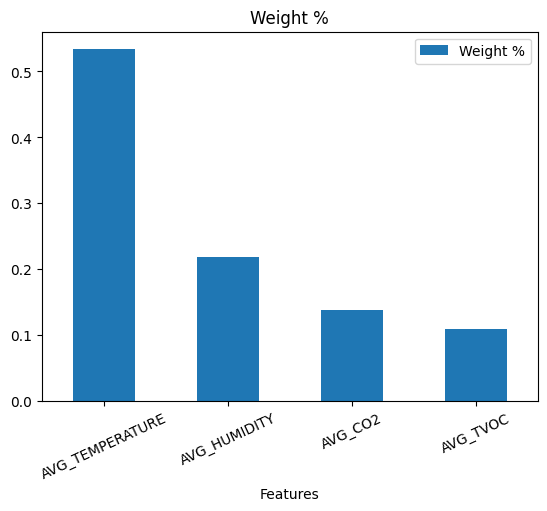

In [42]:
features = varroa_detection_df.drop(["WEIGHTED_SUM", "PREDICTED_ALERT"], axis = 1)
result = utils.random_forest(
            features,
            varroa_detection_df["PREDICTED_ALERT"],
            n_estimators=640
            )[0]

result.set_index("Features", drop=True).plot(kind = "bar",subplots=True)
plt.xticks(rotation = 25)
plt.show()

Note on anonymous trophalaxis